In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src')
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')
# Laptop
sys.path.append('/home/rens/projects/mp_dir/masterproject/src')

from astrometry_equations import predict_G_bv, predict_G_vi
from data_queries import gaia_login, launch_job, get_data
from plotting_functions import set_styles
set_styles()

In [4]:
# REMOVE LATER. NOW HERE FOR TESTING PURPOSES
def predict_G_bv(hp_mag, b_v):
    """Gaia magnitude prediction based on B-V colour from the Gaia handbook"""
    return -0.02392 - 0.4069 * b_v + 0.04569 * (b_v**2) - 0.0452 * (b_v**3) + hp_mag, 0.02417

def predict_G_vi(hp_mag, v_i):
    """Gaia magnitude prediction based on V-I colour from the Gaia handbook"""
    return +0.01546 - 0.4308 * v_i - 0.01872 * (v_i**2) + hp_mag, 0.08181

# Analysis of the Gaia magnitude prediction

In [5]:
# First gather all Hipparcos magnitudes and colours
gaia_login()
query = 'SELECT hip, hp_mag, b_v, v_i, e_hp_mag, e_b_v FROM public.hipparcos_newreduction'
job = launch_job(query)
htable = get_data(job)

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
INFO: Query finished. [astroquery.utils.tap.core]


In [6]:
hip = htable['hip']
hp_mag = htable['hp_mag']
b_v = htable['b_v']
v_i = htable['v_i']

# Predict the Gaia magnitudes based on colour information
g_pred_bv, e_g_pred_bv = predict_G_bv(hp_mag, b_v)
g_pred_vi, e_g_pred_vi = predict_G_vi(hp_mag, v_i)

# Report Plot

In [7]:
hist_style = {'density': False,
              'histtype': 'step',
              'log': True,
              'lw': 3}
def find_edges(x1, x2, nbins):
    data_min = np.nanmin((np.nanmin(x1), np.nanmin(x2)))
    data_max = np.nanmax((np.nanmax(x1), np.nanmax(x2)))
    return np.linspace(data_min, data_max, nbins+1)

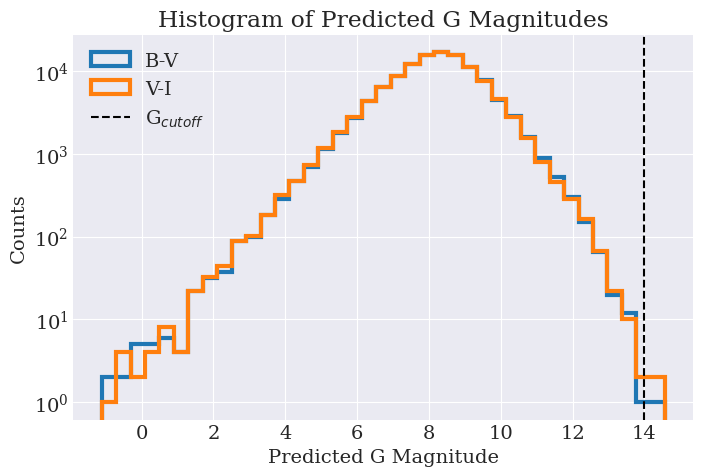

In [8]:
fig, ax = plt.subplots(1,1,figsize=(8,5))

nbins = int(1. + 3.322*np.log(len(g_pred_bv)))
bv_edges = find_edges(g_pred_bv, g_pred_vi, nbins)
ax.hist(g_pred_bv, **hist_style, bins=bv_edges, label='B-V')
ax.hist(g_pred_vi, **hist_style, bins=bv_edges, label='V-I')
ax.axvline(x=14, label=r'G$_{cutoff}$', c='black', ls='--')

ax.set_ylabel('Counts')
ax.set_xlabel('Predicted G Magnitude')
ax.set_title("Histogram of Predicted G Magnitudes")

plt.legend()
plt.savefig('../../../figures/gpred_hist', bbox_inches='tight')
plt.show()

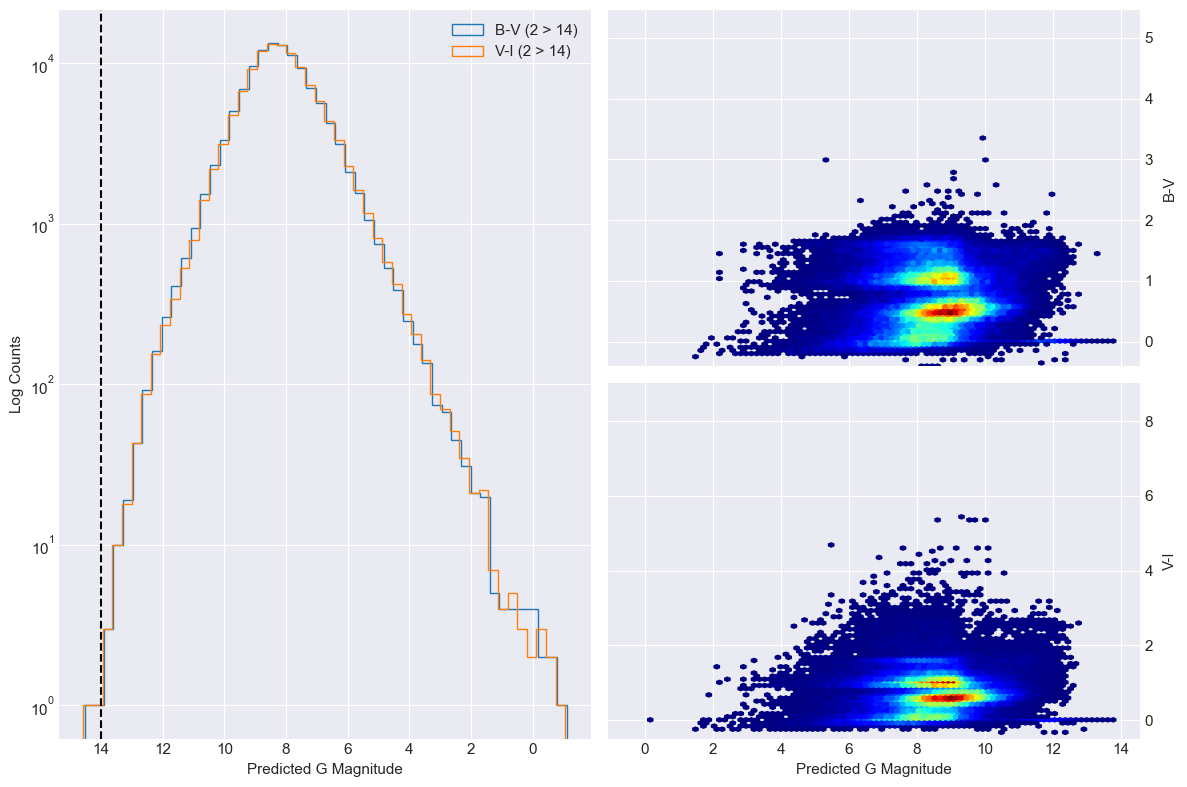

In [98]:
# Plot this information
fig, axs = plt.subplots(2,2, figsize=(12, 8), tight_layout=True, sharex=True)
gs = axs[0, 0].get_gridspec()
for ax in axs[:, 0]:
    ax.remove()
axbig = fig.add_subplot(gs[:,0])

# Gaia predicted histogram
nbins = 50
axbig.hist(g_pred_bv, log=True, bins=nbins, histtype='step', label=f'B-V ({len(g_pred_bv[g_pred_bv > 14])} > 14)', color='C0')
axbig.hist(g_pred_vi, log=True, bins=nbins, histtype='step', label=f'V-I ({len(g_pred_vi[g_pred_vi > 14])} > 14)', color='C1')
axbig.axvline(x=14, c='black', ls='--')
axbig.legend()
axbig.set_xlabel('Predicted G Magnitude')
axbig.set_ylabel('Log Counts')
axbig.invert_xaxis()

# Scatter plots
x_bv = np.linspace(np.min(b_v), np.max(b_v))
x_vi = np.linspace(np.min(v_i), np.max(v_i))

ax_bv = axs[0][1]
ax_vi = axs[1][1]

#ax_bv.scatter(hp_mag, b_v, c='C0', s=1)
ax_bv.hexbin(hp_mag, b_v, cmap='jet', mincnt=2)
#ax_bv.plot(predict_G_bv(0, x_bv)[0], x_bv, c='black', ls='--')
#ax_vi.scatter(hp_mag, v_i, c='C1', s=1)
ax_vi.hexbin(hp_mag, v_i, cmap='jet', mincnt=2)
#ax_vi.plot(predict_G_vi(0, x_vi)[0], x_vi, c='black', ls='--')

for ax in [ax_bv, ax_vi]:
    ax.yaxis.tick_right()
    ax.yaxis.set_label_coords(1.07, 0)
    ax.invert_xaxis()
    ax.set_xlim(np.min(hp_mag), np.max(hp_mag))

ax_bv.set_ylim(np.min(b_v), np.max(b_v))
ax_vi.set_ylim(np.min(v_i), np.max(v_i))

#ax_bv.set_ylim(top=3)


ax_vi.set_xlabel('Predicted G Magnitude')
ax_bv.set_ylabel('B-V')
ax_vi.set_ylabel('V-I')

plt.savefig()
plt.show()